In [30]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import numpy as np
import os



In [31]:
path_df  = "dfNLP/sentiment_mental_health.csv"

# 2. Cargar los datasets
df = pd.read_csv(path_df)

# 3. Verificación de carga
print("==============================================")
print("        DATASET CARGADO CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Test:  {df.shape[0]} filas, {df.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df.head())

        DATASET CARGADO CON ÉXITO           
Dimensiones de Test:  52681 filas, 3 columnas

--- Tipos de datos en Train ---
Unnamed: 0     int64
statement     object
status        object
dtype: object

--- Primeras 5 filas de Train ---


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


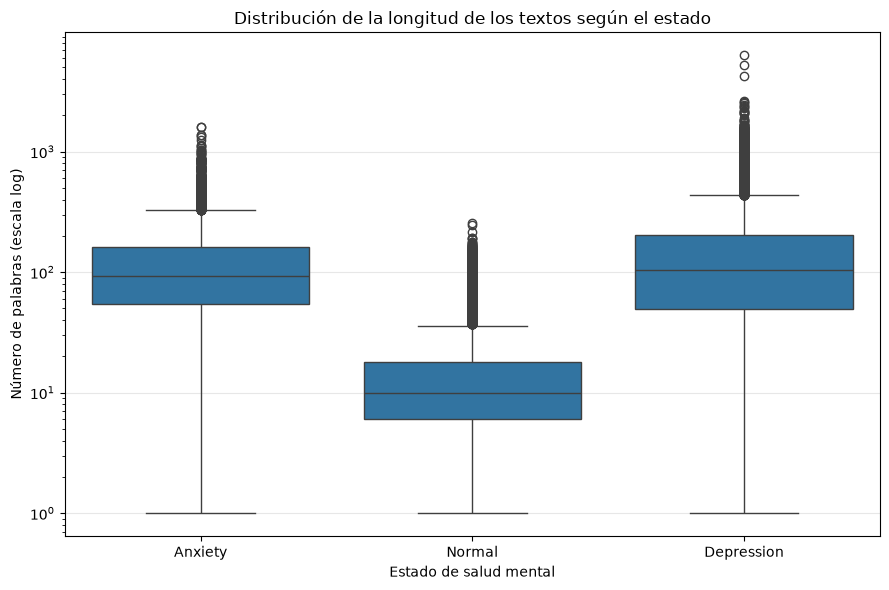

In [32]:
df['statement_length'] = (
    df['statement']
    .fillna('')
    .apply(lambda x: len(x.split()))
)
# Copia para no modificar el DataFrame original
df_plot = df.copy()

# Eliminar categorías que no queremos analizar
df_plot = df_plot[
    df_plot['status'].isin([
        'Normal',
        'Stress',
        'Anxiety',
        'Depression',
        'Suicidal'
    ])
].copy()

# Agrupar categorías
df_plot['status_group'] = df_plot['status'].replace({
    'Stress': 'Anxiety',
    'Anxiety': 'Anxiety',
    'Depression': 'Depression',
    'Suicidal': 'Depression',
    'Normal': 'Normal'
})

# Boxplot
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_plot,
    x='status_group',
    y='statement_length'
)

plt.yscale('log')

plt.xlabel('Estado de salud mental')
plt.ylabel('Número de palabras (escala log)')
plt.title('Distribución de la longitud de los textos según el estado')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
nltk.download("wordnet")

# Stopwords y lematizador
stop_words = set(stopwords.words("english"))
lemmatizer = nltk.WordNetLemmatizer()


def convertir_minusculas(texto):
    return texto.lower()


def eliminar_urls(texto):
    return re.sub(r'http\S+|www\S+', '', texto)


def eliminar_numeros(texto):
    return re.sub(r'\d+', '', texto)


def eliminar_puntuacion(texto):
    return texto.translate(str.maketrans('', '', string.punctuation))


def tokenizar(texto):
    return texto.split()


def eliminar_stopwords(tokens):
    return [palabra for palabra in tokens if palabra not in stop_words]


def lematizar(tokens):
    return [lemmatizer.lemmatize(palabra) for palabra in tokens]


def preprocesar_statement(texto):

    texto = convertir_minusculas(texto)

    texto = eliminar_urls(texto)

    texto = eliminar_numeros(texto)

    texto = eliminar_puntuacion(texto)

    tokens = tokenizar(texto)

    tokens = eliminar_stopwords(tokens)

    tokens = lematizar(tokens)

    return " ".join(tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Samuel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [34]:
df_plot["statement_clean"] = df_plot["statement"].fillna("").apply(preprocesar_statement)
print(df_plot[["statement", "statement_clean"]].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                     statement_clean  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  


Cardinalidad del vocabulario: 66841


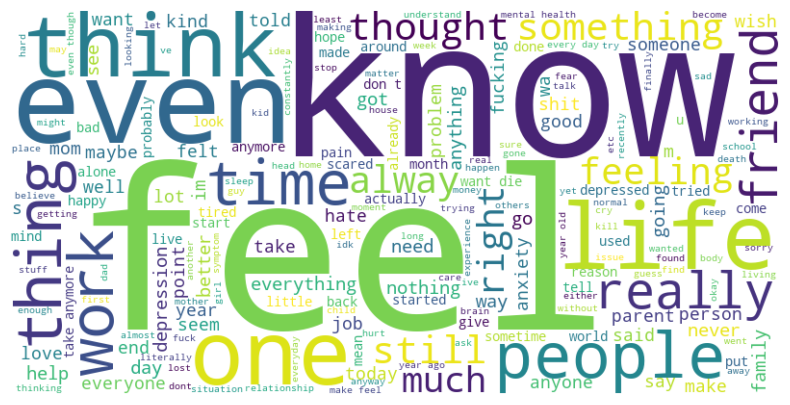

Top 10 Bigramas: ['anymore cannot' 'cannot take' 'even though' 'every day' 'feel like'
 'get better' 'mental health' 'take anymore' 'want die' 'year old']


In [ ]:
textos = df_plot['statement_clean'].dropna().values

# Cardinalidad del vocabulario
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(textos)
vocabulario = vectorizer.get_feature_names_out()
print(f"Cardinalidad del vocabulario: {len(vocabulario)}")

# Nube de palabras
# texto_unido = " ".join(textos)
# wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_unido)
# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")
# plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = ['Anxiety', 'Depression', 'Normal']
df_filtered = df_plot[df_plot['status'].isin(['Anxiety', 'Depression', 'Normal'])].copy()

for ax, cat in zip(axes, categories):
    text_cat = " ".join(df_filtered[df_filtered['status'] == cat]['statement_clean'].astype(str))
    wordcloud = WordCloud(width=400, height=300, background_color='white', stopwords=set(stopwords.words('english'))).generate(text_cat)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Nube de Palabras: {cat}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# N-grams más frecuentes en bigramas
vectorizer_ngram = CountVectorizer(ngram_range=(2, 2), max_features=10)
X_ngram = vectorizer_ngram.fit_transform(textos)
print("Top 10 Bigramas:", vectorizer_ngram.get_feature_names_out())

# N-grams más frecuentes en trigrama
vectorizer_ngram = CountVectorizer(ngram_range=(3, 3), max_features=10)
X_ngram = vectorizer_ngram.fit_transform(textos)

print("Top 10 Trigramas:", vectorizer_ngram.get_feature_names_out())

In [36]:
X = df_plot["statement_clean"]
y = df_plot["status_group"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=46,
    stratify=y
)

In [38]:
# Crear carpeta si no existe
os.makedirs("df_procesado", exist_ok=True)

# Guardar los datasets
X_train.to_csv("df_procesado/X_train.csv", index=False)
X_test.to_csv("df_procesado/X_test.csv", index=False)
y_train.to_csv("df_procesado/y_train.csv", index=False)
y_test.to_csv("df_procesado/y_test.csv", index=False)

print("Datasets guardados correctamente.")

Datasets guardados correctamente.
